# Breathing Ellipse

Let's build a model to learn a velocity field that governs the motion of points on a 2D curve such that the overall shape follows a specific geometric evolution. In this example, we will use a simple ellipse that expands and contracts over time, simulating a breathing motion whose aspect ratio changes according to the following function:

$$
\beta(t) = \frac{1}{2}\left[(\beta_0 + \frac{1}{\beta_0}) + (\beta_0 - \frac{1}{\beta_0})\cos(\frac{\pi t}{T}) \right]; \quad t = 0, 1, ..., T \\
$$

Note the following key time points and their corresponding aspect ratios:

| Time $t$ | Aspect Ratio $\beta(t)$                        |
|----------|------------------------------------------------|
| $0$      | $\beta_0$                                      |
| $T/2$    | $\frac{1}{2}(\beta_0 + \frac{1}{\beta_0})$     |
| $T$      | $\frac{1}{\beta_0}$                            |
| $3T/2$   | $\frac{1}{2}(\beta_0 + \frac{1}{\beta_0})$     |
| $2T$     | $\frac{1}{\beta_0}$                            |

#### Assumptions & Expected Results

- The area of the ellipse is conserved over time.
- Conservation of topology (no crossing of trajectories)
- Each point on the curve maps to a new position at each time step, following the velocity field defined by the Neural ODE.
- **Find time-dependent vector field** that governs the motion of points on the curve.
- Model should show **spatial resolution invariance** (the same curve should be obtained regardless of the number of points sampled on the curve)
- Model should show **time resolution invariance** (the same curve should be obtained regardless of the number of time steps used to sample the curve)

#### Implementation

Our goal is to learn a function $f_{\theta}(X, t)$ that defines the velocity field governing the motion of points on the curve.

$$
\frac{dX}{dt} = f_{\theta}(X, t)
$$

- We use a neural network to learn the function $f_{\theta}(X, t):\mathbb{R}^2 \times \mathbb{R} \rightarrow \mathbb{R}^2$, mapping the current position of points on the curve and time to a velocity vector.
- Then an ODE solver (e.g., `torchdiffeq.odeint`) will be used to compute the output $X(T)$ from the input $X(0)$, given the current velocity field defined by the neural network.
- Loss function: Mean squared error between the predicted curve at time $T$ and the true curve at time $T$.

$$
\mathcal{L}(\theta) = \frac{1}{NK} \sum_{i=1}^{N} \sum_{k=1}^{K} \| X_i^{\theta}(t_k) - X_i^{\text{true}}(t_k) \|^2
$$


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from torchdiffeq import odeint_adjoint as odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
current_nb_dir = Path(".").resolve()
plt.style.use(['science','no-latex'])


## Data Generation

In [2]:
def generate_truth(beta_0, omega, t_final, num_locus_pts, num_time_steps):
    theta = torch.linspace(0, 2 * torch.pi, num_locus_pts).to(device)
    time_values = torch.linspace(0, t_final, num_time_steps).to(device)
    xi = 1.0  # Area constant

    # beta(t) using your sinusoidal function
    a = beta_0 + (1 / beta_0)
    b = beta_0 - (1 / beta_0)
    c = 0.5 * (omega / t_final) * time_values

    # coeff = (1 - beta0**2) / (beta0 * torch.sin(torch.tensor(omega * T)))
    beta_t = 0.5 * (a + (b * torch.cos(c)))

    ellipses = []
    for b in beta_t:
        x = xi * torch.sqrt(b) * torch.cos(theta)
        y = xi * (1 / torch.sqrt(b)) * torch.sin(theta)
        ellipses.append(torch.stack([x, y], dim=1))

    return time_values, torch.stack(ellipses)

In [3]:
BETA_0 = 2.5
OMEGA = 2.0 * torch.pi
T_FINAL = 2.0
NUM_TIME_STEPS = 50  # from 0 to T_FINAL
NUM_LOCUS_POINTS = 100

time_values, ellipses = generate_truth(
    BETA_0, OMEGA, T_FINAL, NUM_LOCUS_POINTS, NUM_TIME_STEPS
)

In [4]:
print(f"Time Values:\n{time_values}\n")  # should list from 0 to T_FINAL
print("Ellipses:")  
print(f"  Shape: {ellipses.shape}")  # (NUM_TIME_STEPS, NUM_LOCUS_POINTS, 2)
print(f"  Dtype: {ellipses.dtype}")

Time Values:
tensor([0.0000, 0.0408, 0.0816, 0.1224, 0.1633, 0.2041, 0.2449, 0.2857, 0.3265,
        0.3673, 0.4082, 0.4490, 0.4898, 0.5306, 0.5714, 0.6122, 0.6531, 0.6939,
        0.7347, 0.7755, 0.8163, 0.8571, 0.8980, 0.9388, 0.9796, 1.0204, 1.0612,
        1.1020, 1.1429, 1.1837, 1.2245, 1.2653, 1.3061, 1.3469, 1.3878, 1.4286,
        1.4694, 1.5102, 1.5510, 1.5918, 1.6327, 1.6735, 1.7143, 1.7551, 1.7959,
        1.8367, 1.8776, 1.9184, 1.9592, 2.0000], device='cuda:0')

Ellipses:
  Shape: torch.Size([50, 100, 2])
  Dtype: torch.float32


## Training

### NN Model for velocity field

The model should take Input: [x, y, t] and then Output: [vx, vy]

In [5]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 750
PRINT_FREQ = 25  # in epochs

In [6]:
class VelocityField(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: [x, y, t] -> Output: [vx, vy]
        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.Tanh(),  # Tanh ensures a smooth, differentiable field
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 2),
        )

    def forward(self, t, h):
        # h: [Batch, 2] | t: scalar
        # Map t to the same shape as the batch
        t_vec = torch.ones(h.shape[0], 1).to(device) * t
        input_data = torch.cat([h, t_vec], dim=1)
        return self.net(input_data)

In [7]:
v_field_nn_model = VelocityField().to(device)
optimizer = optim.Adam(v_field_nn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()  # Define the loss function
t_start = time.time()
t_0 = time.time()
loss_values = []
cum_abs_deviations = []
for i in range(NUM_EPOCHS):
    optimizer.zero_grad()
    init_ellipse = ellipses[0]  # Initial Ellipse at beta0

    # Forward pass: Integrated path through the ODE solver
    pred_traj = odeint(v_field_nn_model, init_ellipse, time_values)

    # Loss: MSE between predicted trajectories and true snapshots
    loss = criterion(pred_traj, ellipses)
    loss.backward()
    optimizer.step()
    loss_values.append([i, loss.item()])

    if i % (PRINT_FREQ) == 0:
        with torch.no_grad():
            cum_abs_deviations.append(
                [i, torch.abs(pred_traj-ellipses).sum().item()]
            )
            epoch_str = f"Epoch {i + 1}/{NUM_EPOCHS}"
            loss_str = f"Loss: {loss.item():.8f}"
            elps_t = f"elapsed time: {time.time() - t_0:.2f}"
            print(f"{epoch_str} | {loss_str} | {elps_t}")
            t_0 = time.time()

print(f"training completed in {time.time() - t_start:.2f}s")

# Saving the model
model_fp = current_nb_dir.joinpath("be_v_field_model.pth")  # Save model
torch.save(v_field_nn_model.state_dict(), model_fp)
print(f"Model saved to {model_fp}")

Epoch 1/750 | Loss: 0.15952386 | elapsed time: 4.81
Epoch 26/750 | Loss: 0.02465119 | elapsed time: 161.38
Epoch 51/750 | Loss: 0.00760853 | elapsed time: 161.98
Epoch 76/750 | Loss: 0.00663802 | elapsed time: 176.87
Epoch 101/750 | Loss: 0.00636197 | elapsed time: 160.32
Epoch 126/750 | Loss: 0.00613407 | elapsed time: 161.78
Epoch 151/750 | Loss: 0.00593593 | elapsed time: 157.33
Epoch 176/750 | Loss: 0.00574720 | elapsed time: 158.77
Epoch 201/750 | Loss: 0.00555523 | elapsed time: 161.05
Epoch 226/750 | Loss: 0.00534770 | elapsed time: 159.85
Epoch 251/750 | Loss: 0.00511065 | elapsed time: 158.26
Epoch 276/750 | Loss: 0.00482633 | elapsed time: 157.95
Epoch 301/750 | Loss: 0.00447122 | elapsed time: 156.78
Epoch 326/750 | Loss: 0.00401560 | elapsed time: 161.29
Epoch 351/750 | Loss: 0.00343020 | elapsed time: 158.69
Epoch 376/750 | Loss: 0.00271127 | elapsed time: 163.17
Epoch 401/750 | Loss: 0.00192493 | elapsed time: 161.74
Epoch 426/750 | Loss: 0.00121073 | elapsed time: 157.85

### Visualization of training history

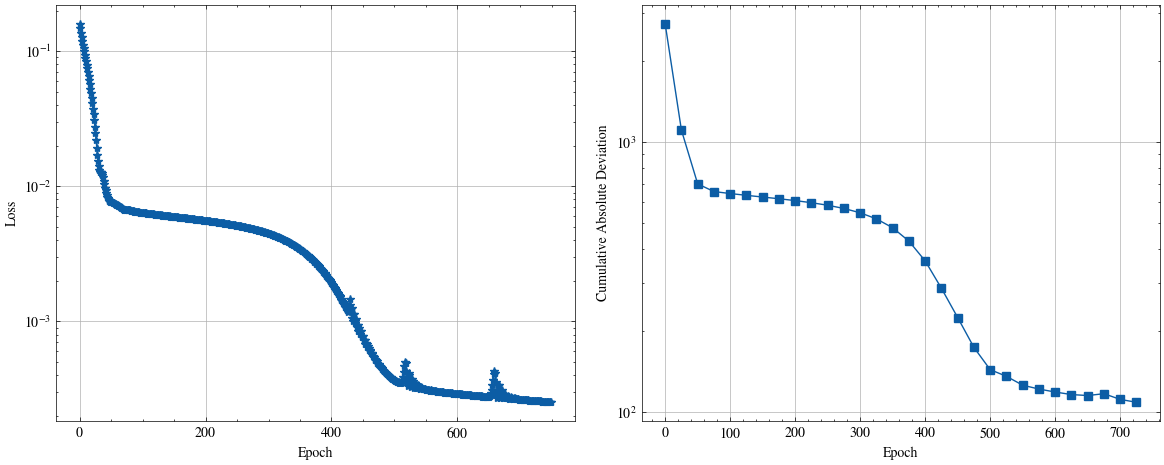

In [8]:
loss_values = np.array(loss_values)
cum_abs_deviations = np.array(cum_abs_deviations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.rcParams['font.size'] = 15.0

ax1.plot(loss_values[:, 0], loss_values[:, 1], marker='*')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_yscale('log')
ax1.grid()

ax2.plot(cum_abs_deviations[:, 0], cum_abs_deviations[:, 1], marker='s')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Cumulative Absolute Deviation")
ax2.set_yscale('log')
ax2.grid()

plt.tight_layout()
plt.show()


## Inference

In [9]:
if not model_fp.exists():
    raise FileNotFoundError(f"Model file {model_fp}")
print(f"Loading model from {model_fp} ...")

model_inf = VelocityField().to(device)
model_inf.load_state_dict(torch.load(model_fp))
model_inf.eval()
print("Model loaded successfully.")

Loading model from /home/rajesh/work/ml/neural_ode/breathing_ellipse/be_v_field_model.pth ...
Model loaded successfully.


In [14]:
def plot_inference(
    pred_traj: torch.Tensor,
    true_traj: torch.Tensor,
    t_val: torch.Tensor,
    fp_out=None,
):
    pred_traj = pred_traj.cpu().numpy()
    true_traj = true_traj.cpu().numpy()
    num_t, num_p, _ = pred_traj.shape

    fig, axs = plt.subplots(figsize=(6, 6), dpi=80)

    # # Create a line object
    (line,) = axs.plot([], [], "r-", lw=2)

    # --- Create static limits once ---
    axs.set_xlim(-3, 3)
    axs.set_ylim(-3, 3)
    axs.set_aspect("equal")
    axs.grid(True, alpha=0.3)
    title = axs.set_title("Breathing Ellipse | t = 0.00")

    # Plot Velocity Field
    xx, yy = np.meshgrid(np.linspace(-3, 3, 15), np.linspace(-3, 3, 15))
    grid = torch.tensor(
        np.stack([xx.flatten(), yy.flatten()], axis=1), dtype=torch.float32
    ).to(device)

    def init():
        line.set_data([], [])
        return line, title

    def _add_line(arr, frm, **plot_kwargs):
        x = arr[frm, :, 0]
        y = arr[frm, :, 1]
        x_closed = np.append(x, x[0])
        y_closed = np.append(y, y[0])
        (line,) = axs.plot(x_closed, y_closed, **plot_kwargs)
        return line

    def update(frame):
        axs.clear()
        t_val_i = t_val[frame].item()

        line = _add_line(
            pred_traj,
            frame,
            color="red",
            linestyle="solid",
            lw=2,
            label="Predicted Ellipse",
        )
        line = _add_line(
            true_traj,
            frame,
            color="b",
            linestyle="solid",
            lw=2,
            label="True Ellipse",
        )

        axs.set_title(f"Breathing Ellipse | Time = {t_val_i:.3f} sec")

        with torch.no_grad():
            v = model_inf(torch.tensor(t_val_i).to(device), grid).cpu().numpy()

        axs.quiver(xx, yy, v[:, 0], v[:, 1], color="lightgray")

        axs.grid(True, alpha=0.3)
        axs.set_aspect("equal")
        axs.legend(loc="upper right")
        return line, title

    ani = FuncAnimation(
        fig, update, frames=num_t, init_func=init, interval=50, blit=True
    )
    plt.close(fig)
    if fp_out is not None:
        ani.save(fp_out, writer='ffmpeg', fps=15)
    else:
        return HTML(ani.to_jshtml())

### Predict with same time steps and spatial resolution as training

In [15]:
new_num_locus_points = NUM_LOCUS_POINTS
new_num_time_steps = NUM_TIME_STEPS
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_n_same_t.mp4"),
)

{{< video case_same_n_same_t.mp4 width="600" aspect-ratio="8x8" >}}

### Predict with finer time steps (4 times more), but same spatial resolution as training

In [16]:
new_num_locus_points = NUM_LOCUS_POINTS
new_num_time_steps = NUM_TIME_STEPS * 4
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_n.mp4"),
)

{{< video case_same_n.mp4 width="600" aspect-ratio="8x8" >}}

### Predict with same time steps, but coarser spatial resolution as training

In [17]:
new_num_locus_points = NUM_LOCUS_POINTS // 6
new_num_time_steps = NUM_TIME_STEPS
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_t.mp4"),
)

{{< video case_same_t.mp4 width="600" aspect-ratio="8x8" >}}

## True velocity field derivation


$$
\dfrac{x^2}{a(t)^2} + \dfrac{y^2}{b(t)^2} = 1 \\
$$

Assuming the ellipse is centered at the origin, parametrized by the angle $\theta \in [0, 2\pi)$, the coordinates of points on the ellipse can be expressed as:

$$
x(t, \theta) = a(t) \cos{\theta} \\
y(t, \theta) = b(t) \sin{\theta}
$$

Where $a(t)$ and $b(t)$ are the semi-major and semi-minor axes of the ellipse at time $t$. The aspect ratio $\beta(t)$ is defined as:

$$
\beta(t) = \frac{a(t)}{b(t)} \\
\beta(0) = \beta_0 \\
\beta(T) = \frac{1}{\beta_0}
$$

As the area of the ellipse is conserved, we have:

$$
\begin{align*}
A &= \pi a(t) b(t) = \text{constant} \\
\Rightarrow a(t) b(t) &= A / \pi = \xi ^ 2 \\
\Rightarrow a(t) &= \xi \sqrt{\beta(t)} \\
\Rightarrow b(t) &= \frac{\xi}{\sqrt{\beta(t)}} \\
x(t, \theta) &= \xi \sqrt{\beta(t)} \cos{\theta} \\
y(t, \theta) &= \frac{\xi}{\sqrt{\beta(t)}} \sin{\theta} \\
\end{align*}
$$

Differentiating the coordinates with respect to time to get the velocity field:

$$
\begin{align*}
\frac{dx}{dt} &= \frac{d}{dt} (\xi \sqrt{\beta(t)} \cos{\theta}) \\
&= \xi \cos{\theta} \frac{d}{dt} \sqrt{\beta(t)} \\
&= \frac{\xi}{2} \cos{\theta} \frac{\beta'(t)}{\sqrt{\beta(t)}} \\
\Rightarrow \frac{dx}{dt} &= \frac{x}{2} \frac{\beta'(t)}{\beta(t)} \\
\end{align*}
$$

Similarly for $y$:

$$
\begin{align*}
\frac{dy}{dt} &= \frac{d}{dt} \left( \frac{\xi}{\sqrt{\beta(t)}} \sin{\theta} \right) \\
&= -\frac{\xi}{2} \sin{\theta} \frac{\beta'(t)}{\beta(t)\sqrt{\beta(t)}} \\
\Rightarrow \frac{dy}{dt} &= -\frac{y}{2} \frac{\beta'(t)}{\beta(t)}
\end{align*}
$$

Hence, the velocity field governing the motion of points on the curve can be expressed as:

$$
\begin{align*}
\frac{d}{dt} \begin{pmatrix} x \\ y \end{pmatrix} &= \alpha(t) \begin{pmatrix} x \\ -y \end{pmatrix} \\
&= \frac{\beta'(t)}{2\beta(t)} \begin{pmatrix} x \\ -y \end{pmatrix}
\end{align*}
$$

The neural ODE should learn this time-varying velocity field that governs the motion of points on the curve, allowing it to reconstruct the breathing ellipse dynamics from the observed data.